# 4. Unstable and marginally stable orbits

**Photon sphere.** A photon at $r = 3$ with $b = 3\sqrt3$ circles forever in exact arithmetic, but any perturbation $\delta_0$ grows like $e^{t/3\sqrt3}$, a factor $e^{2\pi} \approx 535$ per orbit. The integration error is the perturbation. The orbit is tilted by 45° because the equatorial photon sphere is an exact fixed point of every Runge–Kutta map. Figure F10 has the full study.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geoint.plotting import style

style.apply()
%matplotlib inline

orbits gained per decade of tolerance: 0.33 (predicted 0.37)


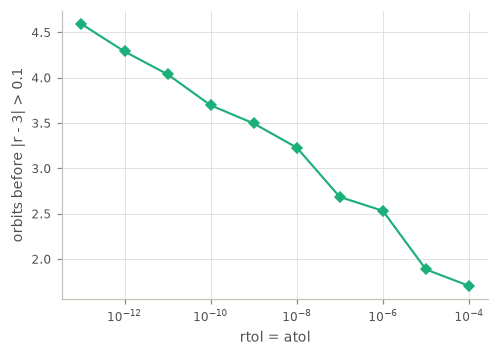

In [2]:
import math

from geoint.experiments import RunSpec, run_many
from geoint.testcases.schwarzschild import PhotonSphere

case = PhotonSphere(math.inf, 45.0)
tols = np.geomspace(1e-4, 1e-13, 10)
df = run_many([RunSpec.make(case, "b", "DOP853", rtol=t, atol=t) for t in tols])
slope = -np.polyfit(np.log10(df["opt_rtol"]), df["orbits"], 1)[0]
predicted = math.log(10) / (2 * math.pi)
print(f"orbits gained per decade of tolerance: {slope:.2f} (predicted {predicted:.2f})")
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.semilogx(df["opt_rtol"], df["orbits"], **style.method_style("DOP853"))
ax.set(xlabel="rtol = atol", ylabel="orbits before |r - 3| > 0.1");

**ISCO.** At $r = 6$ the effective potential has an inflection point. An integration error acts as a small constant force $\varepsilon$, $\ddot\delta = \varepsilon - \delta^2/1296$ with $r = 6 + \delta$. For $\varepsilon < 0$ the orbit plunges after a time $\propto |\varepsilon|^{-1/4}$; with steps $h$ and order $p$ that is $\propto n^{p/4}$ in the steps per orbit $n$. GL2 has $p = 4$, so the time to plunge should grow roughly in proportion to $n$ (figure F11).

In [3]:
from geoint.testcases.schwarzschild import MarginalCircular

isco = MarginalCircular(45.0, 2000.0)
spo = [10, 20, 40, 80]
df = run_many(
    [RunSpec.make(isco, "b", "GL2", n_steps=int(isco.n_orbits * n), save_every=n) for n in spo]
)
print(df[["opt_n_steps", "exit", "orbits"]])
print("slope:", np.polyfit(np.log(spo), np.log(df["orbits"]), 1)[0])

   opt_n_steps     exit     orbits
0        20000  plunged   2.434525
1        40000  plunged   6.755510
2        80000  plunged  15.000412
3       160000  plunged  31.595712
slope: 1.224491594340197
